# Gold as an Investment: How Does It Behave in Different Economic Conditions?

**Team:** Kenyee Liu, Yifan Chen  
**API/Data Source:** Alpha Vantage: Macrotrends, Gold, Silver, and Copper price records for the past 60 years

Gold is often viewed as a "safe-haven" investment. Many investors believe that gold performs well during periods of inflation or economic uncertainty. However, it is not always clear how gold actually behaves compared to other metals or economic indicators.

In this project, we analyze historical data on **gold, silver, copper, inflation, and GDP growth** to understand how gold behaves under different economic conditions.

### Our analysis focuses on several key questions:

- Does gold perform better during **high inflation periods**?
- How does gold compare with **other metals** such as silver and copper?
- Is gold **more stable** than other metals?
- How do macroeconomic conditions influence metal prices?

To answer these questions, we combine **data quality checks, feature engineering, SQL analysis, visualizations, and regression models**. The goal is to translate historical patterns into insights that are clear and useful for our target audience: **non-expert investors**.

---

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 as sq

## 1. Download data using an API / CSV

We pull three macro series:
- **Real GDP (annual)** — overall economic output
- **Inflation (annual)** — price level change rate
- **Gold Price (monthly)** — Gold Price per ounce
- **Silver Price (monthly)** — Silver Price per ounce
- **Copper Price (daily)** — Copper Price per ounce

### 1.1 API requests

In [2]:
response_GDP = requests.get('https://www.alphavantage.co/query?function=REAL_GDP&interval=annual&apikey=3S9Z5G5I5U5BWSJI')

for r in response_GDP.json():
    print(r)

name
interval
unit
data


In [3]:
response_Inflation = requests.get('https://www.alphavantage.co/query?function=INFLATION&apikey=6FN6U353TY65IABQ')

for r in response_Inflation.json():
    print(r)

name
interval
unit
data


### 1.2 Convert JSON responses to DataFrames

In [7]:
GDP = pd.DataFrame(response_GDP.json()['data'])
Inflation = pd.DataFrame(response_Inflation.json()['data'])

### 1.3 Import CSV files

In [8]:
copper = pd.read_csv("copper.csv")
silver = pd.read_csv("silver.csv")
Gold = pd.read_csv("gold.csv")

copper["Date"] = pd.to_datetime(copper["Date"])
silver["Date"] = pd.to_datetime(silver["Date"])
Gold["Date"] = pd.to_datetime(Gold["Date"])

In [9]:
copper["Date"] = pd.to_datetime(copper["Date"], format="%m/%d/%Y")
silver["Date"] = pd.to_datetime(silver["Date"], format="%m/%d/%Y")
Gold["Date"] = pd.to_datetime(Gold["Date"], format="%m/%d/%Y")

## 2.Data Quality Checks

Before conducting any analysis, it is important to verify that the dataset is reliable and consistent.

In this section we check:

- whether the datasets contain **missing values**
- whether there are **duplicate records**
- whether there are **unusual values** that might indicate errors
- whether numeric columns are stored as **correct data types**

Metal prices and GDP should never be negative, but inflation may occasionally be negative during economic downturns (US typical inflation: -3% to 15% according to https://tradingeconomics.com/united-states/inflation-cpi). Therefore, negative inflation values do not necessarily indicate an error.

These checks ensure that the data is suitable for further analysis. 

### 2.1 Preview the raw tables

In [10]:
GDP

,date,value
0,2025-01-01,23864.462
1,2024-01-01,23358.435
2,2023-01-01,22723.719
3,2022-01-01,22075.931
4,2021-01-01,21532.407
...,...,...
92,1933-01-01,877.431
93,1932-01-01,888.414
94,1931-01-01,1019.977
95,1930-01-01,1089.785


In [11]:
Inflation

,date,value
0,2024-01-01,2.94952520485207
1,2023-01-01,4.11633838374488
2,2022-01-01,8.00279982052121
3,2021-01-01,4.69785886363742
4,2020-01-01,1.23358439630629
...,...,...
60,1964-01-01,1.27891156462591
61,1963-01-01,1.23966942148753
62,1962-01-01,1.19877334820186
63,1961-01-01,1.07072414764724


In [12]:
Gold

,Date,Value
0,1915-01-01,19.2500
1,1915-02-01,19.2500
2,1915-03-01,19.2500
3,1915-04-01,19.2500
4,1915-05-01,19.2500
...,...,...
1330,2025-11-01,4217.3637
1331,2025-12-01,4322.3617
1332,2026-01-01,4865.3500
1333,2026-02-01,5277.8900


In [13]:
silver

,Date,Value
0,1915-01-01,0.5100
1,1915-02-01,0.5100
2,1915-03-01,0.5100
3,1915-04-01,0.5100
4,1915-05-01,0.5100
...,...,...
1330,2025-11-01,56.5422
1331,2025-12-01,71.6490
1332,2026-01-01,113.9528
1333,2026-02-01,93.6600


In [14]:
copper

,Date,Value
0,1959-07-02,0.2930
1,1959-07-06,0.2910
2,1959-07-07,0.2820
3,1959-07-08,0.2846
4,1959-07-09,0.2760
...,...,...
16836,2026-03-02,5.9456
16837,2026-03-03,5.8576
16838,2026-03-04,5.9040
16839,2026-03-05,5.8064


### 2.2 Missing Values

Missing values can reduce the reliability of an analysis, especially when they affect key variables such as prices, inflation, or GDP. Therefore, we first check whether any of the raw datasets contain missing observations.

In [15]:
GDP.isna().sum()
Inflation.isna().sum()
Gold.isna().sum()
silver.isna().sum()
copper.isna().sum()

Date     0
Value    0
dtype: int64

### 2.3 Duplicate Values (Dates)

Because this project analyzes historical time series, each date or year should generally appear only once in each annual dataset. Duplicate records could distort averages, trends, and regression results.

We therefore check for duplicate dates before merging the datasets.

In [23]:
#Duplicate Dates
GDP['date'].duplicated().sum()
Inflation['date'].duplicated().sum()
Gold['Date'].duplicated().sum()
silver['Date'].duplicated().sum()
copper['Date'].duplicated().sum()

np.int64(0)

### 2.4 Oddities

After checking missing values and duplicates, the next step is to look for unusual values that might indicate data problems.

For this project, some variables should never be negative. For example, **gold, silver, and copper prices should always be positive**. In contrast, macroeconomic variables such as **inflation** or **GDP growth** can sometimes be negative during deflation or economic contraction. This distinction matters because not every unusual-looking value is necessarily an error.

In [24]:
GDP["value"] = pd.to_numeric(GDP["value"], errors="coerce")
Inflation["value"] = pd.to_numeric(Inflation["value"], errors="coerce")
Gold["Value"] = pd.to_numeric(Gold["Value"], errors="coerce")
silver["Value"] = pd.to_numeric(silver["Value"], errors="coerce")
copper["Value"] = pd.to_numeric(copper["Value"], errors="coerce")

In [91]:
print("Checking for odd values")

print("GDP:", (GDP['value'] <= 0).sum())
print("Inflation:", (Inflation['value'] < 0).sum())
print("Gold:", (Gold['Value'] < 0).sum())
print("Silver:", (silver['Value'] < 0).sum())
print("Copper:", (copper['Value'] < 0).sum())

Checking for odd values
GDP: 0
Inflation: 1
Gold: 0
Silver: 0
Copper: 0


### 2.5 Data Types

Even when values look reasonable, analysis can still fail if numeric columns are stored as text. This is common when data is downloaded from APIs or imported from CSV files.

We therefore verify the data types and convert relevant columns into numeric or datetime format where needed. This is an essential preparation step for later calculations such as percentage changes, correlations, and regression models.

In [29]:
GDP.info()

<class 'pandas.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    97 non-null     str    
 1   value   97 non-null     float64
dtypes: float64(1), str(1)
memory usage: 2.6 KB


In [30]:
Inflation.info()

<class 'pandas.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    65 non-null     str    
 1   value   65 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.8 KB


In [31]:
Inflation["value"].describe()

count    65.000000
mean      3.757704
std       2.743010
min      -0.355546
25%       1.898048
50%       3.015075
75%       4.300535
max      13.549202
Name: value, dtype: float64

In [32]:
Gold.info()

<class 'pandas.DataFrame'>
RangeIndex: 1335 entries, 0 to 1334
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1335 non-null   datetime64[us]
 1   Value   1335 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 21.0 KB


In [33]:
silver.info()

<class 'pandas.DataFrame'>
RangeIndex: 1335 entries, 0 to 1334
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1335 non-null   datetime64[us]
 1   Value   1335 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 21.0 KB


In [34]:
copper.info()

<class 'pandas.DataFrame'>
RangeIndex: 16841 entries, 0 to 16840
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    16841 non-null  datetime64[us]
 1   Value   16841 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 263.3 KB


**Interpretation:** The API returns both dates and numeric values as **strings**, which cannot be used directly for calculations. Therefore, we convert:
- `date` → datetime
- numeric fields (`value`, `price`) → numeric

This allows correct later calculations such as calculating percentage changes, correlations, and regression models.

---

## 3. Match frequencies and merge

The datasets used in this project come from different sources and are recorded at different time frequencies:
- GDP: annual
- Inflation: annual
- Gold: monthly
- Silver: monthly
- Copper: daily

To make the datasets comparable, we convert all data to a **consistent annual format** and merge them by year. This allows us to analyze how metal prices move alongside macroeconomic variables such as inflation and GDP growth.

After merging, we obtain a single dataset that contains all relevant variables needed for the analysis.

### 3.1 Quick check: what is the latest GDP year label?

In [35]:
GDP.sort_values("date").tail()

,date,value
4,2021-01-01,21532.407
3,2022-01-01,22075.931
2,2023-01-01,22723.719
1,2024-01-01,23358.435
0,2025-01-01,23864.462


### 3.2 Convert date columns

In [101]:
GDP['date'] = pd.to_datetime(GDP['date'], errors='coerce')
Inflation['date'] = pd.to_datetime(Inflation['date'], errors='coerce')

### 3.3 Match time frequencies and merge

In [38]:
# Matching Time Frequencies
GDP_raw = GDP.copy()
Inflation_raw = Inflation.copy()
Gold_raw = Gold.copy()
copper_raw = copper.copy()
silver_raw = silver.copy()

GDP_raw['year'] = GDP_raw['date'].dt.year
Inflation_raw['year'] = Inflation_raw['date'].dt.year
Gold_raw['year'] = Gold_raw['Date'].dt.year
copper_raw['year'] = copper_raw['Date'].dt.year
silver_raw['year'] = silver_raw['Date'].dt.year


GDP_annual = GDP_raw.groupby('year', as_index=False)['value'].mean()
Inflation_annual = Inflation_raw.groupby('year', as_index=False)['value'].mean()
Gold_annual = Gold_raw.groupby('year', as_index=False)['Value'].mean()
copper_annual = copper_raw.groupby('year', as_index=False)['Value'].mean()
silver_annual = silver_raw.groupby('year', as_index=False)['Value'].mean()

# Merge on year
GDP_annual = GDP_annual.rename(columns={'value': 'Real GDP'})
Inflation_annual = Inflation_annual.rename(columns={'value': 'Inflation Rate'})
Gold_annual = Gold_annual.rename(columns={'Value': 'Gold Price'})
copper_annual = copper_annual.rename(columns={'Value': 'Copper Price'})
silver_annual = silver_annual.rename(columns={'Value': 'Silver Price'})

macro_annual = (GDP_annual.merge(Inflation_annual, on='year', how='inner')
                .merge(Gold_annual, on='year', how='inner')
                .merge(silver_annual, on='year', how='inner')
                .merge(copper_annual, on='year', how='inner')
                .sort_values('year')
                .reset_index(drop=True)
               )

macro_annual

,year,Real GDP,Inflation Rate,Gold Price,Silver Price,Copper Price
0,1960,3500.272,1.457976,35.310000,0.920000,0.298338
1,1961,3590.066,1.070724,35.310000,0.930000,0.298112
2,1962,3810.124,1.198773,35.310000,1.090000,0.292455
3,1963,3976.142,1.239669,35.310000,1.292250,0.297616
4,1964,4205.277,1.278912,35.310000,1.298250,0.403233
...,...,...,...,...,...,...
60,2020,20284.500,1.233584,1784.657500,20.796133,2.801286
61,2021,21532.407,4.697859,1792.731667,24.968133,4.244540
62,2022,22075.931,8.002800,1798.956575,21.671767,3.984608
63,2023,22723.719,4.116338,1953.688517,23.579675,3.873046


In [39]:
columns_need_checking = ['Real GDP','Inflation Rate','Gold Price','Silver Price','Copper Price']
for column in columns_need_checking:
    print(f"{column}:")
    print("Negative vlaues:", (macro_annual[column]<0).sum())
    print("Null values:", macro_annual[column].isna().sum())

Real GDP:
Negative vlaues: 0
Null values: 0
Inflation Rate:
Negative vlaues: 1
Null values: 0
Gold Price:
Negative vlaues: 0
Null values: 0
Silver Price:
Negative vlaues: 0
Null values: 0
Copper Price:
Negative vlaues: 0
Null values: 0


The negative value for inflation rate is normal as mentioned

In [40]:
macro_annual.describe()

,year,Real GDP,Inflation Rate,Gold Price,Silver Price,Copper Price
count,65.00000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,1992.00000,11619.813662,3.757704,582.487297,9.420095,1.502305
std,18.90767,5809.887315,2.743010,589.608385,8.346785,1.202308
min,1960.00000,3500.272000,-0.355546,35.310000,0.920000,0.292455
25%,1976.00000,6387.437000,1.898048,160.412500,4.342500,0.658485
50%,1992.00000,10398.046000,3.015075,368.225000,5.419167,0.914470
75%,2008.00000,16762.445000,4.300535,880.208333,14.975833,2.502823
max,2024.00000,23358.435000,13.549202,2404.577567,35.556667,4.244540


*Typical inflation values in the United States generally fall between approximately **–3% and 15%** over long historical periods. Therefore, small negative inflation values (deflation) can occur and should not automatically be treated as errors.*

*By comparing the inflation values in our dataset with known historical ranges, we confirm that the values fall within a reasonable range and appear consistent with real economic conditions.*

---

## 4. Feature engineering

Raw price levels alone do not provide enough information about how markets behave. Investors are typically more interested in **changes in prices**, rather than the price level itself.

Therefore, we create several new variables:
- **GDP growth (%)**: year-to-year percent change in Real GDP  
- **Gold change (%)**: year-to-year percent change in gold price
- **Silver change (%)**: year-to-year percent change in gold price
- **Copper change (%)**: year-to-year percent change in gold price
- **Inflation change**: change in the inflation rate in **percentage points**, which is more meaningful than percent change of a percent

Two especially important engineered features are **`gold_inflation_gap`** and **`gold_gdp_gap`**, which are added in later analysis. These variables measure how much gold’s annual return exceeds inflation and GDP growth, respectively. They are useful because they move the analysis beyond asking whether gold simply went up in price and instead ask whether gold outperformed key economic benchmarks.

These features help answer our questions about how metal prices respond to different economic environments.

In [41]:
macro_annual['Gdp Growth(%)'] = macro_annual['Real GDP'].pct_change()*100
macro_annual['Gold %Change'] = macro_annual['Gold Price'].pct_change()*100
macro_annual['Silver %Change'] = macro_annual['Silver Price'].pct_change()*100
macro_annual['Copper %Change'] = macro_annual['Copper Price'].pct_change()*100
macro_annual['Inflation %Change'] = macro_annual['Inflation Rate'].diff()
macro_annual

,year,Real GDP,Inflation Rate,Gold Price,Silver Price,Copper Price,Gdp Growth(%),Gold %Change,Silver %Change,Copper %Change,Inflation %Change
0,1960,3500.272,1.457976,35.310000,0.920000,0.298338,NaN,NaN,NaN,NaN,NaN
1,1961,3590.066,1.070724,35.310000,0.930000,0.298112,2.565343,0.000000,1.086957,-0.076052,-0.387252
2,1962,3810.124,1.198773,35.310000,1.090000,0.292455,6.129637,0.000000,17.204301,-1.897544,0.128049
3,1963,3976.142,1.239669,35.310000,1.292250,0.297616,4.357286,0.000000,18.555046,1.764900,0.040896
4,1964,4205.277,1.278912,35.310000,1.298250,0.403233,5.762747,0.000000,0.464306,35.487412,0.039242
...,...,...,...,...,...,...,...,...,...,...,...
60,2020,20284.500,1.233584,1784.657500,20.796133,2.801286,-2.081376,26.992511,27.101745,2.918493,-0.578626
61,2021,21532.407,4.697859,1792.731667,24.968133,4.244540,6.152022,0.452421,20.061422,51.521121,3.464274
62,2022,22075.931,8.002800,1798.956575,21.671767,3.984608,2.524214,0.347230,-13.202295,-6.123916,3.304941
63,2023,22723.719,4.116338,1953.688517,23.579675,3.873046,2.934363,8.601205,8.803659,-2.799825,-3.886461


### 4.1 Clean column names for easier analysis

In [42]:
macro_annual = macro_annual.rename(columns={
    'Gdp Growth(%)': 'gdp_growth_pct',
    'Gold %Change': 'gold_change_pct',
    'Silver %Change': 'silver_change_pct',
    'Copper %Change': 'copper_change_pct',
    'Inflation %Change': 'inflation_change'
})
macro_annual

,year,Real GDP,Inflation Rate,Gold Price,Silver Price,Copper Price,gdp_growth_pct,gold_change_pct,silver_change_pct,copper_change_pct,inflation_change
0,1960,3500.272,1.457976,35.310000,0.920000,0.298338,NaN,NaN,NaN,NaN,NaN
1,1961,3590.066,1.070724,35.310000,0.930000,0.298112,2.565343,0.000000,1.086957,-0.076052,-0.387252
2,1962,3810.124,1.198773,35.310000,1.090000,0.292455,6.129637,0.000000,17.204301,-1.897544,0.128049
3,1963,3976.142,1.239669,35.310000,1.292250,0.297616,4.357286,0.000000,18.555046,1.764900,0.040896
4,1964,4205.277,1.278912,35.310000,1.298250,0.403233,5.762747,0.000000,0.464306,35.487412,0.039242
...,...,...,...,...,...,...,...,...,...,...,...
60,2020,20284.500,1.233584,1784.657500,20.796133,2.801286,-2.081376,26.992511,27.101745,2.918493,-0.578626
61,2021,21532.407,4.697859,1792.731667,24.968133,4.244540,6.152022,0.452421,20.061422,51.521121,3.464274
62,2022,22075.931,8.002800,1798.956575,21.671767,3.984608,2.524214,0.347230,-13.202295,-6.123916,3.304941
63,2023,22723.719,4.116338,1953.688517,23.579675,3.873046,2.934363,8.601205,8.803659,-2.799825,-3.886461


### 4.2 Load engineered tables into SQLite

In [70]:
conn = sq.connect("gold_analysis.db")

GDP_annual.to_sql("GDP_annual", conn, if_exists="replace", index=False)
Inflation_annual.to_sql("Inflation_annual", conn, if_exists="replace", index=False)
Gold_annual.to_sql("Gold_annual", conn, if_exists="replace", index=False)
silver_annual.to_sql("silver_annual", conn, if_exists="replace", index=False)
copper_annual.to_sql("copper_annual", conn, if_exists="replace", index=False)
macro_annual.to_sql("macro_annual", conn, if_exists="replace", index=False)

65

In [71]:
pd.read_sql("""
SELECT name
From sqlite_master
WHERE type = 'table';
""", conn)

,name
0,GDP_annual
1,Inflation_annual
2,Gold_annual
3,silver_annual
4,copper_annual
5,macro_annual


---

## 5. Exploratory Data Analysis (EDA)

With the cleaned and merged dataset prepared, we now move into exploratory analysis.

The purpose of EDA is to understand the broad patterns in the data before drawing stronger conclusions. In this section, we examine:

- missing values after feature engineering
- summary statistics
- time-series trends
- correlations
- subgroup comparisons
- SQL summaries
- regression results

The goal is to use them to build a clear story about how gold behaves as an investment and reveal real-world implications.

### 5.1 Check missing values after feature engineering

Whenever new variables are created, it is important to check whether that process introduced missing values.

This is especially relevant for percentage-change variables, because the first year in a series usually has no previous year to compare with. Therefore, some missing values are expected and should not automatically be treated as a problem.

In [46]:
macro_annual.isna().sum()

year                 0
Real GDP             0
Inflation Rate       0
Gold Price           0
Silver Price         0
Copper Price         0
gdp_growth_pct       1
gold_change_pct      1
silver_change_pct    1
copper_change_pct    1
inflation_change     1
dtype: int64

In [47]:
macro_annual.head()

,year,Real GDP,Inflation Rate,Gold Price,Silver Price,Copper Price,gdp_growth_pct,gold_change_pct,silver_change_pct,copper_change_pct,inflation_change
0,1960,3500.272,1.457976,35.31,0.92000,0.298338,NaN,NaN,NaN,NaN,NaN
1,1961,3590.066,1.070724,35.31,0.93000,0.298112,2.565343,0.0,1.086957,-0.076052,-0.387252
2,1962,3810.124,1.198773,35.31,1.09000,0.292455,6.129637,0.0,17.204301,-1.897544,0.128049
3,1963,3976.142,1.239669,35.31,1.29225,0.297616,4.357286,0.0,18.555046,1.764900,0.040896
4,1964,4205.277,1.278912,35.31,1.29825,0.403233,5.762747,0.0,0.464306,35.487412,0.039242


### Note on First-Row NaNs in Change Features
The first row contains missing values for variables such as `gdp_growth_pct`, `inflation_change`, and metal return measures because these features are based on year-to-year changes.

Since the first year has **no prior year** to compare against, these missing values are expected. We keep the row for transparency, but analyses that depend on change variables will use only the rows where those features are available.

### 5.2 Summary statistics for the variables

Summary statistics provide a quick overview of the dataset. They show the center, spread, and range of each variable, which helps confirm that the values look reasonable and also gives an early sense of scale.

For a non-expert audience, this step is useful because it answers simple but important questions such as:

- Which variables vary the most?
- How large are typical changes in metal prices?
- Do any variables appear especially volatile or extreme?

In [47]:
macro_annual.describe()

,year,Real GDP,Inflation Rate,Gold Price,Silver Price,Copper Price,gdp_growth_pct,gold_change_pct,silver_change_pct,copper_change_pct,inflation_change
count,65.00000,65.000000,65.000000,65.000000,65.000000,65.000000,64.000000,64.000000,64.000000,64.000000,64.000000
mean,1992.00000,11619.813662,3.757704,582.487297,9.420095,1.502305,3.031204,8.664887,8.737101,6.225179,0.023305
std,18.90767,5809.887315,2.743010,589.608385,8.346785,1.202308,2.087456,21.628331,28.775480,21.842994,1.791969
min,1960.00000,3500.272000,-0.355546,35.310000,0.920000,0.292455,-2.576500,-26.026477,-48.602969,-27.523959,-4.203288
25%,1976.00000,6387.437000,1.898048,160.412500,4.342500,0.658485,2.246293,-2.548518,-9.595091,-7.367641,-0.844180
50%,1992.00000,10398.046000,3.015075,368.225000,5.419167,0.914470,2.956028,1.272718,0.843636,0.087284,0.126917
75%,2008.00000,16762.445000,4.300535,880.208333,14.975833,2.502823,4.379746,15.270203,18.738614,17.825584,1.011846
max,2024.00000,23358.435000,13.549202,2404.577567,35.556667,4.244540,7.236453,89.348859,127.735677,83.950352,4.877045


### 5.3 Time-Series Plots

The time-series plots show how each major variable changes over time.

These graphs are important because they allow us to see long-run patterns that are difficult to notice from tables alone. In particular, we plot both:
- **levels** (Real GDP, Inflation Rate, Gold Price, Silver Price, Copper Price) to understand the general direction across years
- **change features** (GDP growth %, inflation change, gold change %, silver change %, copper change%) to see volatility.

Several patterns can be observed:
- **GDP** generally trends upward over long periods, reflecting long-term economic growth.
- **Inflation** shows periods of both stability and spikes, particularly during economic crises.
- **Metal prices** fluctuate significantly over time, reflecting changes in supply, demand, and investor behavior.

These patterns highlight the importance of examining both macroeconomic conditions and commodity markets together.

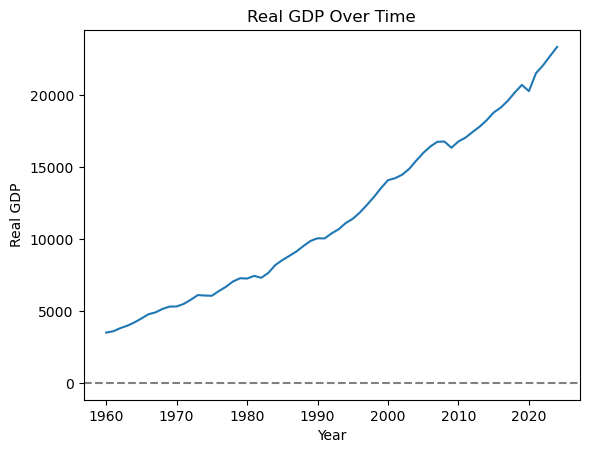

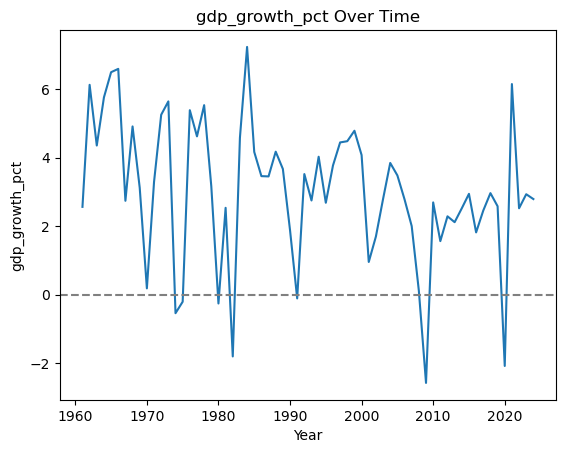

In [48]:
for col in ['Real GDP', 'gdp_growth_pct']:
    plt.figure()
    plt.plot(macro_annual['year'], macro_annual[col])
    plt.title(f'{col} Over Time')
    plt.xlabel('Year')
    plt.ylabel(col)
    plt.axhline(0, color='gray', linestyle='--')
    plt.show()

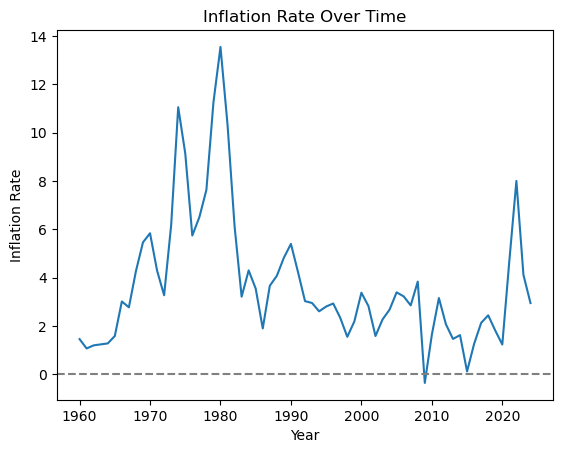

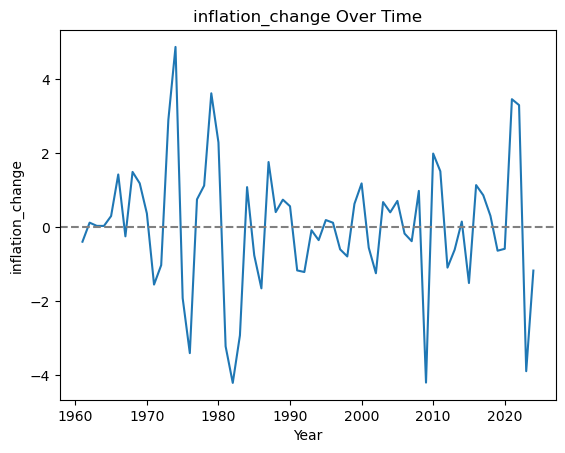

In [49]:
for col in ['Inflation Rate', 'inflation_change']:
    plt.figure()
    plt.plot(macro_annual['year'], macro_annual[col])
    plt.title(f'{col} Over Time')
    plt.xlabel('Year')
    plt.ylabel(col)
    plt.axhline(0, color='gray', linestyle='--')
    plt.show()

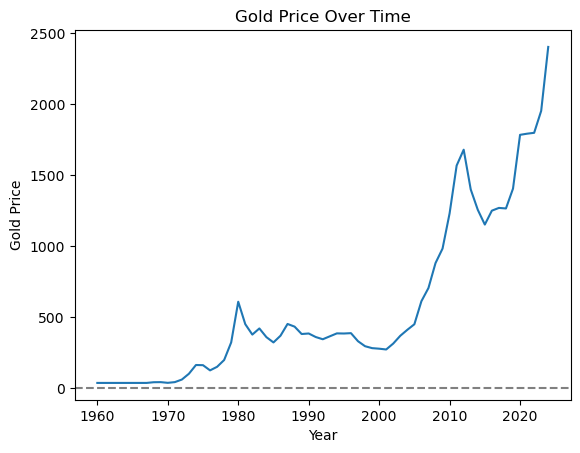

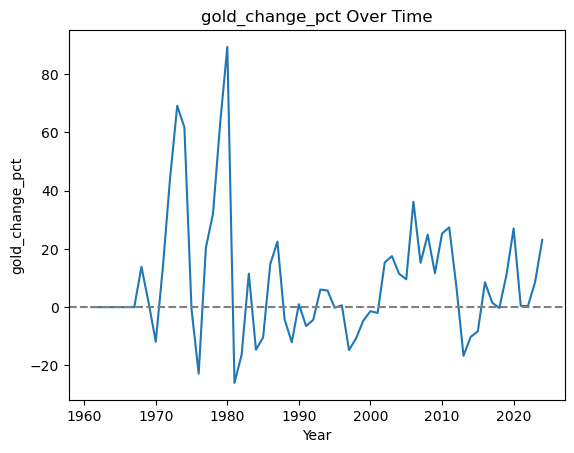

In [50]:
for col in ['Gold Price', 'gold_change_pct']:
    plt.figure()
    plt.plot(macro_annual['year'], macro_annual[col])
    plt.title(f'{col} Over Time')
    plt.xlabel('Year')
    plt.ylabel(col)
    plt.axhline(0, color='gray', linestyle='--')
    plt.show()

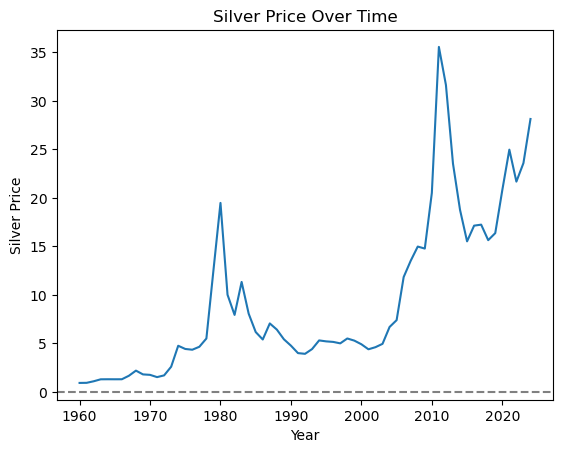

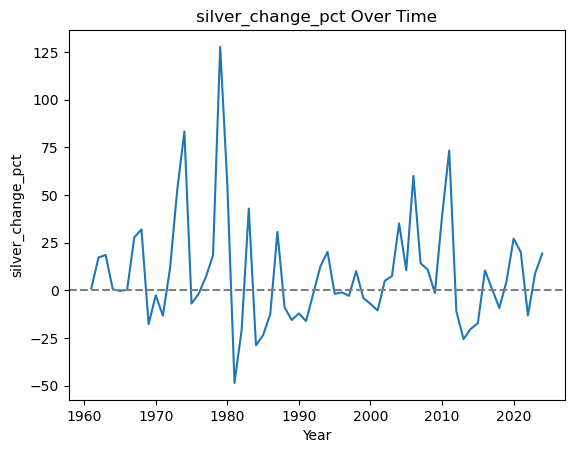

In [51]:
for col in ['Silver Price', 'silver_change_pct']:
    plt.figure()
    plt.plot(macro_annual['year'], macro_annual[col])
    plt.title(f'{col} Over Time')
    plt.xlabel('Year')
    plt.ylabel(col)
    plt.axhline(0, color='gray', linestyle='--')
    plt.show()

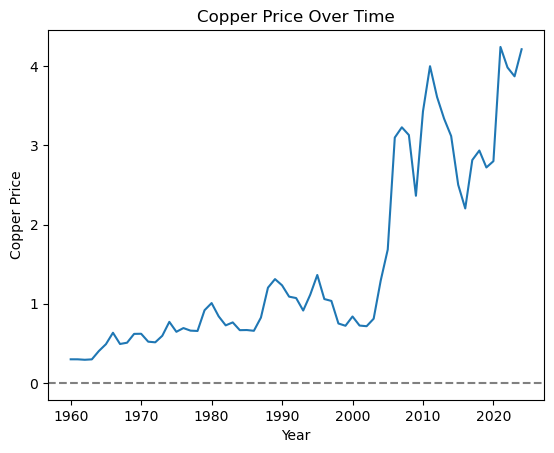

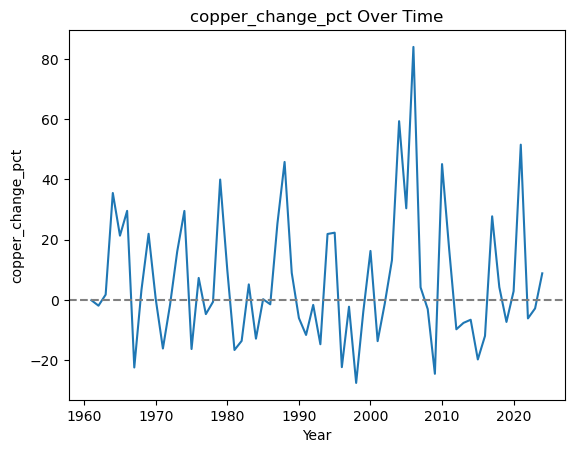

In [52]:
for col in ['Copper Price', 'copper_change_pct']:
    plt.figure()
    plt.plot(macro_annual['year'], macro_annual[col])
    plt.title(f'{col} Over Time')
    plt.xlabel('Year')
    plt.ylabel(col)
    plt.axhline(0, color='gray', linestyle='--')
    plt.show()

**Interpretation of the Time-Series Plots**

The time-series charts show that both macroeconomic conditions and metal prices change substantially across decades.

Several broad patterns stand out:
- GDP generally rises over time, reflecting long-run economic growth.
- Inflation fluctuates much more sharply, with some periods of especially high inflation.
- Gold, silver, and copper prices all trend upward in the long run, but they do not move in exactly the same way.

These differences suggest that metal prices are influenced by both shared market forces and metal-specific economic roles. This is one reason why it is useful to **compare gold with silver and copper** in later analysis.

### 5.4 Correlations

The correlation heatmap provides a quick overview of how strongly different variables move together.

Values close to **1** indicate strong positive relationships, while values close to **–1** indicate strong negative relationships.

In [53]:
corr = macro_annual[['Real GDP', 'Inflation Rate', 'Gold Price', 'Silver Price', 'Copper Price',
                     'gdp_growth_pct', 'inflation_change','gold_change_pct', 'silver_change_pct', 'copper_change_pct']].corr()
corr

,Real GDP,Inflation Rate,Gold Price,Silver Price,Copper Price,gdp_growth_pct,inflation_change,gold_change_pct,silver_change_pct,copper_change_pct
Real GDP,1.000000,-0.298592,0.883516,0.777970,0.878965,-0.278765,-0.022501,-0.043556,-0.051252,0.047543
Inflation Rate,-0.298592,1.000000,-0.162557,-0.023721,-0.169993,-0.153605,0.318319,0.414666,0.294400,0.089616
Gold Price,0.883516,-0.162557,1.000000,0.931891,0.936385,-0.289920,-0.024502,0.035212,0.008823,0.008870
Silver Price,0.777970,-0.023721,0.931891,1.000000,0.906777,-0.307503,0.035057,0.158667,0.157421,0.056167
Copper Price,0.878965,-0.169993,0.936385,0.906777,1.000000,-0.267782,0.050308,0.048125,0.060923,0.147211
gdp_growth_pct,-0.278765,-0.153605,-0.289920,-0.307503,-0.267782,1.000000,0.212391,-0.157222,-0.041604,0.242252
inflation_change,-0.022501,0.318319,-0.024502,0.035057,0.050308,0.212391,1.000000,0.470792,0.489983,0.464622
gold_change_pct,-0.043556,0.414666,0.035212,0.158667,0.048125,-0.157222,0.470792,1.000000,0.784098,0.333896
silver_change_pct,-0.051252,0.294400,0.008823,0.157421,0.060923,-0.041604,0.489983,0.784098,1.000000,0.493559
copper_change_pct,0.047543,0.089616,0.008870,0.056167,0.147211,0.242252,0.464622,0.333896,0.493559,1.000000


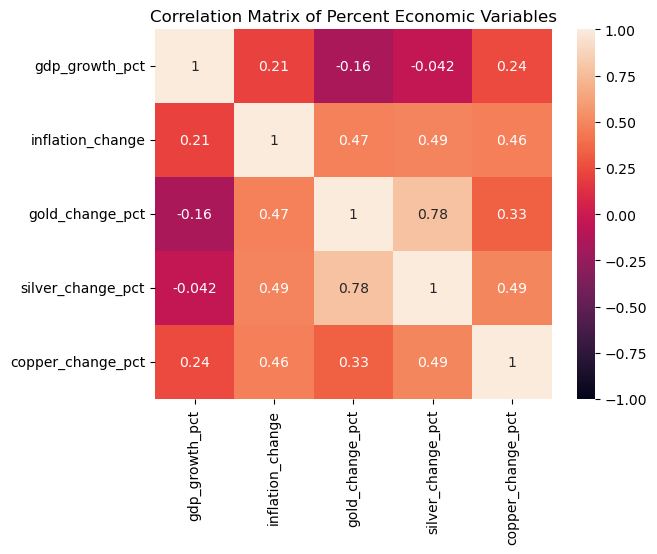

In [54]:
corr_percent = macro_annual[
[
"gdp_growth_pct",
"inflation_change",
"gold_change_pct",
"silver_change_pct",
"copper_change_pct"
]
].corr()

plt.figure()

sns.heatmap(corr_percent, annot=True, vmin=-1, vmax=1)

plt.title("Correlation Matrix of Percent Economic Variables")

plt.show()

**Interpretation of the Correlation Heatmap**

The heatmap summarizes the pairwise correlations among the main variables.

Values close to **1** indicate that two variables tend to move together, while values close to **-1** indicate that they tend to move in opposite directions. Values near **0** suggest a weak linear relationship.

One important pattern is that **gold and silver tend to move more closely together than gold and copper**, which is consistent with the idea that gold and silver are both precious metals. At the same time, the macroeconomic variables show weaker direct correlations with metal returns, suggesting that these effects are more complex than a simple one-to-one relationship.

### 5.5 Subgroup Analysis: High vs Low Inflation and GDP Growth Years

Averages over the full sample can hide important differences across economic environments. Because one of the main goals of this project is to understand when gold performs better, we first split the data into broader macroeconomic groups:

- **High inflation** vs **low inflation** years
- **High GDP growth** vs **low GDP growth** years

These groups are based on the median value of each variable. Creating them makes later comparisons easier to interpret and prepares the dataset for both charts and SQL analysis.

In [55]:
median_inflation = macro_annual['Inflation Rate'].median()
macro_annual['Inflation Group'] = macro_annual['Inflation Rate'].apply(
    lambda x: 'High Inflation' if x >= median_inflation else 'Low Inflation'
)
median_gdp_growth = macro_annual['gdp_growth_pct'].median()
macro_annual['GDP Growth Group'] = macro_annual['gdp_growth_pct'].apply(
    lambda x: 'High GDP Growth' if x >= median_gdp_growth else 'Low GDP Growth'
)
macro_annual

,year,Real GDP,Inflation Rate,Gold Price,Silver Price,Copper Price,gdp_growth_pct,gold_change_pct,silver_change_pct,copper_change_pct,inflation_change,Inflation Group,GDP Growth Group
0,1960,3500.272,1.457976,35.310000,0.920000,0.298338,NaN,NaN,NaN,NaN,NaN,Low Inflation,Low GDP Growth
1,1961,3590.066,1.070724,35.310000,0.930000,0.298112,2.565343,0.000000,1.086957,-0.076052,-0.387252,Low Inflation,Low GDP Growth
2,1962,3810.124,1.198773,35.310000,1.090000,0.292455,6.129637,0.000000,17.204301,-1.897544,0.128049,Low Inflation,High GDP Growth
3,1963,3976.142,1.239669,35.310000,1.292250,0.297616,4.357286,0.000000,18.555046,1.764900,0.040896,Low Inflation,High GDP Growth
4,1964,4205.277,1.278912,35.310000,1.298250,0.403233,5.762747,0.000000,0.464306,35.487412,0.039242,Low Inflation,High GDP Growth
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,2020,20284.500,1.233584,1784.657500,20.796133,2.801286,-2.081376,26.992511,27.101745,2.918493,-0.578626,Low Inflation,Low GDP Growth
61,2021,21532.407,4.697859,1792.731667,24.968133,4.244540,6.152022,0.452421,20.061422,51.521121,3.464274,High Inflation,High GDP Growth
62,2022,22075.931,8.002800,1798.956575,21.671767,3.984608,2.524214,0.347230,-13.202295,-6.123916,3.304941,High Inflation,Low GDP Growth
63,2023,22723.719,4.116338,1953.688517,23.579675,3.873046,2.934363,8.601205,8.803659,-2.799825,-3.886461,High Inflation,Low GDP Growth


In [94]:
query_1 = """
-- Summarizes gold performance under different inflation regimes & count high and low inflation years for later analysis.
-- How: Groups the merged annual dataset by Inflation Group and calculates the number of years, average gold price, and average gold annual return for each group.
-- Purpose: This helps evaluate whether gold tends to perform differently in high-inflation versus low-inflation environments, which is central to the project’s analysis.

SELECT
    [Inflation Group] AS inflation_group,
    [GDP Growth Group] AS gdp_group,
    COUNT(*) AS year,
    ROUND(AVG([Gold Price]), 2) AS avg_gold_price,
    ROUND(AVG("gold_change_pct"), 2) AS avg_gold_change_pct
FROM macro_annual
GROUP BY [Inflation Group], [GDP Growth Group]
ORDER BY inflation_group;
"""

gold_inflation_gdp = pd.read_sql(query_1, conn)
gold_inflation_gdp

,inflation_group,gdp_group,year,avg_gold_price,avg_gold_change_pct
0,High Inflation,High GDP Growth,20,316.51,11.62
1,High Inflation,Low GDP Growth,13,718.98,14.46
2,Low Inflation,High GDP Growth,12,321.66,0.19
3,Low Inflation,Low GDP Growth,20,916.24,6.94


**Interpretation of the Grouped Gold Summary**

This SQL summary compares gold performance across combinations of inflation and GDP growth groups.

Two patterns already stand out. First, gold tends to perform better when **inflation is high** than when inflation is low. Second, the strongest average gold returns appear in conditions that are usually considered economically uncomfortable for consumers, especially when inflation is elevated and growth is not especially strong.

This table provides the first broad macroeconomic picture of where gold seems most attractive.

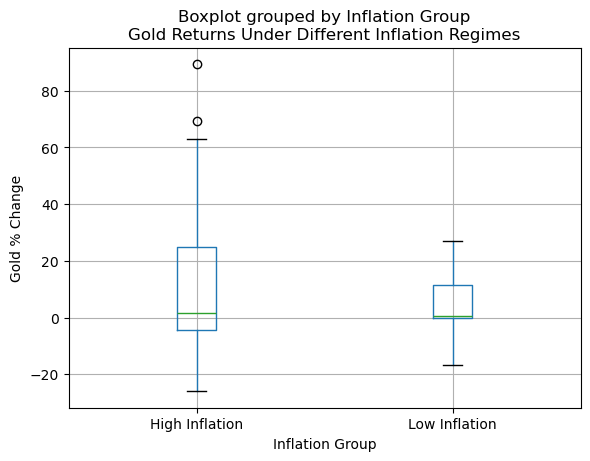

In [96]:
macro_annual.boxplot(column="gold_change_pct", by="Inflation Group")
plt.title("Gold Returns Under Different Inflation Regimes")
plt.ylabel("Gold % Change")
plt.show()

**Interpretation of the Inflation Boxplot**

The boxplot reinforces the SQL summary by showing the full distribution of gold returns in high- and low-inflation years.

The median gold return is higher during **high inflation periods**, and the high-inflation group also contains several very large positive outliers. In other words, gold not only performs better on average in those periods, but some of its strongest years also happen when inflation is elevated.

For consumers, this suggests that gold may be especially attractive during inflationary environments, although returns still vary considerably from year to year.

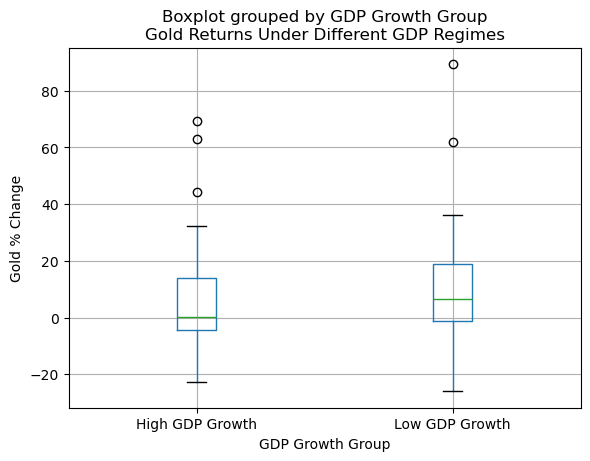

In [98]:
macro_annual.boxplot(column="gold_change_pct", by="GDP Growth Group")
plt.title("Gold Returns Under Different GDP Regimes")
plt.ylabel("Gold % Change")
plt.show()

**Interpretation of the GDP Growth Boxplot**

The GDP boxplot compares gold returns during high-growth and low-growth years.

Gold returns appear more favorable in weaker-growth environments, which is consistent with the idea that gold becomes more appealing when the broader economy is under stress. During stronger-growth periods, gold can still perform well, but the distribution is less dominated by extreme positive years.

This visual pattern helps motivate the more detailed SQL analysis of GDP conditions that comes later.

## 5.6 SQL Analysis: Building the Economic Story Step by Step

The next set of analyses uses SQL to answer focused economic questions. These queries are organized from broad to specific:

1. identify the strongest gold years
2. study gold under inflation conditions
3. study gold under GDP growth conditions
4. compare gold with silver and copper
5. combine metals and macroeconomic regimes
6. examine gold’s longer-run trend

### 5.6.1 Strongest Gold Years: When Did Gold Rise the Most?

After the broad subgroup comparisons, the next step is to look directly at the years when gold performed best.

Ranking the strongest gold years helps answer a simple question: **what kind of economic environment tends to surround gold’s biggest gains?**

This section first identifies the top 10 gold-return years and then examines their inflation and GDP conditions.

In [62]:
query_2 = """
-- Identifies the years with the strongest gold price increases.
-- How: Uses a window function (RANK() OVER) to rank years by gold_change_pct from highest to lowest.
-- Purpose: This helps reveal the macroeconomic conditions associated with the 10 strongest gold growth years, allowing comparison with inflation and GDP trends.

SELECT
    year,
    gold_change_pct,
    [Inflation Rate],
    gdp_growth_pct,
    RANK() OVER (ORDER BY gold_change_pct DESC) AS gold_growth_rank
FROM macro_annual
WHERE gold_change_pct IS NOT NULL
ORDER BY gold_growth_rank, year
LIMIT 10;
"""

gold_increase_rank = pd.read_sql(query_2, conn)
gold_increase_rank

,year,gold_change_pct,Inflation Rate,gdp_growth_pct,gold_growth_rank
0,1980,89.348859,13.549202,-0.256776,1
1,1973,69.136725,6.177760,5.645680,2
2,1979,63.100506,11.254471,3.165988,3
3,1974,61.753304,11.054805,-0.540550,4
4,1972,44.255492,3.272278,5.255502,5
5,2006,36.206209,3.225944,2.784540,6
6,1978,32.122077,7.630964,5.535206,7
7,2011,27.398605,3.156842,1.564407,8
8,2020,26.992511,1.233584,-2.081376,9
9,2010,25.248585,1.640043,2.695193,10


In [63]:
query_3 = """
-- Following query_2, examines the macroeconomic environment during the strongest gold growth years.
-- How: Uses a window function to rank gold returns and then retrieves their inflation group, inflation rate, and GDP growth conditions.
-- Purpose: This helps determine whether strong gold performance tends to occur under specific macroeconomic regimes, such as high inflation or weak economic growth.

SELECT
    year,
    [Inflation Group] AS inflation_group,
    [Inflation Rate] AS inflation_rate,
    [GDP Growth Group] AS gdp_growth_group,
    gdp_growth_pct,
    gold_change_pct,
    RANK() OVER (ORDER BY gold_change_pct DESC) AS gold_rank
FROM macro_annual
ORDER BY gold_rank, year
LIMIT 10;
"""

strongest_gold_inflation_gdp = pd.read_sql(query_3, conn)
strongest_gold_inflation_gdp

,year,inflation_group,inflation_rate,gdp_growth_group,gdp_growth_pct,gold_change_pct,gold_rank
0,1980,High Inflation,13.549202,Low GDP Growth,-0.256776,89.348859,1
1,1973,High Inflation,6.177760,High GDP Growth,5.645680,69.136725,2
2,1979,High Inflation,11.254471,High GDP Growth,3.165988,63.100506,3
3,1974,High Inflation,11.054805,Low GDP Growth,-0.540550,61.753304,4
4,1972,High Inflation,3.272278,High GDP Growth,5.255502,44.255492,5
5,2006,High Inflation,3.225944,Low GDP Growth,2.784540,36.206209,6
6,1978,High Inflation,7.630964,High GDP Growth,5.535206,32.122077,7
7,2011,High Inflation,3.156842,Low GDP Growth,1.564407,27.398605,8
8,2020,Low Inflation,1.233584,Low GDP Growth,-2.081376,26.992511,9
9,2010,Low Inflation,1.640043,Low GDP Growth,2.695193,25.248585,10


**Interpretation of the Strongest Gold Years**

This query identifies the **top 10 years with the highest gold returns**.

Among these strongest years, **7 occurred during high inflation periods**, and **6 occurred during low GDP growth environments**.
- This pattern suggests that gold tends to perform particularly well when economic conditions are uncertain, especially when inflation is high or economic growth is weak. That is consistent with gold’s reputation as a safe asset.

### 5.7 Strong Gold Performance Under Different Inflation Conditions

One of the most common reasons people invest in gold is the belief that it performs well during inflationary periods. If prices in the economy are rising quickly, consumers may worry that cash is losing purchasing power and may look for assets that can better preserve value.

This section focuses specifically on **inflation**. The goal is to examine whether gold can still outperform better in **high-inflation years** than in **low-inflation years**, and whether gold’s return is strong enough to meaningfully outpace inflation.

To make this analysis more informative, we use the engineered feature **`gold_inflation_gap`**, which measures the difference between gold’s annual return and the inflation rate. This helps answer a practical question for consumers:

**Does gold merely increase in price during inflationary periods, or does it actually rise faster than inflation?**

To better identify meaningful gold performance, this analysis focuses only on years in which gold's annual return was **above its long-run average return**.

This filter helps highlight the years when gold performed **exceptionally well**, rather than simply looking at typical annual movements. By focusing on above-average gold years, we can more clearly observe whether these strong gold performances tend to occur during **high-inflation environments**.

In [64]:
macro_annual['gold_inflation_gap'] = macro_annual['gold_change_pct'] - macro_annual['Inflation Rate']

In [72]:
query_4 = """
-- Identifies high-inflation years in which gold outperformed its overall average annual return (15/33), combined with query_1.
-- How: Joins the gold, inflation, and merged macroeconomic tables by year, then filters for High Inflation years where gold_change_pct is greater than the overall average gold return from a subquery.
-- Purpose: This helps test whether high inflation is associated with unusually strong gold performance, which is central to evaluating gold as an inflation hedge.

SELECT
    g.year,
    m.[Inflation Group] AS inflation_group,
    i.[Inflation Rate] AS inflation_rate,
    g.[Gold Price] AS gold_price,
    m.gold_change_pct,
    m.gold_inflation_gap
FROM Gold_annual g
JOIN Inflation_annual i ON g.year = i.year
JOIN macro_annual m ON g.year = m.year
WHERE m.[Inflation Group] = 'High Inflation'
    AND m.gold_change_pct > (
        SELECT AVG(gold_change_pct) FROM macro_annual
        )
ORDER BY i.[Inflation Rate] DESC, m.gold_change_pct DESC;
"""

gold_outperform_high_inflation = pd.read_sql(query_4, conn)
gold_outperform_high_inflation

,year,inflation_group,inflation_rate,gold_price,gold_change_pct,gold_inflation_gap
0,1980,High Inflation,13.549202,607.762500,89.348859,75.799657
1,1979,High Inflation,11.254471,320.975000,63.100506,51.846035
2,1974,High Inflation,11.054805,161.679167,61.753304,50.698499
3,1978,High Inflation,7.630964,196.795833,32.122077,24.491113
4,1977,High Inflation,6.501684,148.950000,20.323124,13.821440
5,1973,High Inflation,6.177760,99.954167,69.136725,62.958965
6,1971,High Inflation,4.292767,40.966667,13.841095,9.548328
7,1968,High Inflation,4.271796,40.202500,13.855848,9.584052
8,2008,High Inflation,3.839100,880.208333,24.909828,21.070728
9,1987,High Inflation,3.664563,451.091667,22.504356,18.839793


**Interpretation of Gold Performance in High-Inflation Years**

This query focuses on high-inflation periods and identifies the years in which gold returns were above their long-run average. Because the query filters for above-average gold years, the results highlight periods when gold performed particularly strongly.  **Among the 33 high-inflation years, gold outperformed in 15 years (45.45%)**, suggesting that inflationary environments are often associated with unusually strong gold performance.

Because the output also includes `gold_inflation_gap`, we can go one step further than simply asking whether gold increased. We can also ask whether gold rose **faster than inflation itself**.

The results show that in a substantial share of high-inflation years, gold not only performed well in absolute terms, but also helped offset inflation. This makes the analysis more meaningful for consumers, since the key issue is not just whether gold goes up, but whether it helps preserve purchasing power when prices are rising quickly.

In [73]:
query_4_2 = """
-- Identifies low-inflation years in which gold outperformed its overall average annual return (10/32), combined with query_1.
-- How: Joins the gold, inflation, and merged macroeconomic tables by year, then filters for low Inflation years where gold_change_pct is greater than the overall average gold return from a subquery.
-- Purpose: This helps test whether low inflation is associated with unusually strong gold performance, which is central to evaluating gold as an inflation hedge.

SELECT
    g.year,
    m.[Inflation Group] AS inflation_group,
    i.[Inflation Rate] AS inflation_rate,
    g.[Gold Price] AS gold_price,
    m.gold_change_pct,
    m.gold_inflation_gap
FROM Gold_annual g
JOIN Inflation_annual i ON g.year = i.year
JOIN macro_annual m ON g.year = m.year
WHERE m.[Inflation Group] = 'Low Inflation'
    AND m.gold_change_pct > (
        SELECT AVG(gold_change_pct) FROM macro_annual
        )
ORDER BY i.[Inflation Rate] DESC, m.gold_change_pct DESC;
"""

gold_outperform_low_inflation = pd.read_sql(query_4_2, conn)
gold_outperform_low_inflation

,year,inflation_group,inflation_rate,gold_price,gold_change_pct,gold_inflation_gap
0,2024,Low Inflation,2.949525,2404.577567,23.078861,20.129335
1,2007,Low Inflation,2.852672,704.675000,15.230055,12.377383
2,2004,Low Inflation,2.677237,409.808333,11.474555,8.797318
3,2003,Low Inflation,2.270095,367.625000,17.503696,15.233601
4,1986,Low Inflation,1.898048,368.225000,14.771429,12.873381
5,2019,Low Inflation,1.812210,1405.325000,11.040218,9.228008
6,2010,Low Inflation,1.640043,1230.750000,25.248585,23.608541
7,2002,Low Inflation,1.586032,312.862500,15.390644,13.804613
8,2020,Low Inflation,1.233584,1784.657500,26.992511,25.758926
9,2009,Low Inflation,-0.355546,982.645833,11.637870,11.993416


**Interpretation of Gold Outperformance in Low-Inflation Years**

This query identifies low-inflation years in which gold still exceeded its long-run average return. **Among the 32 low-inflation years, gold outperformed inflaiton in 10 years (31.25%).**

The fact that these years exist is important because it shows that gold does not depend entirely on inflation to perform well. However, compared with the high-inflation results, gold’s role as a purchasing-power hedge is less obvious in these calmer inflation environments.

Taken together, the high- and low-inflation results suggest that gold can perform well in many settings, **but its defensive value is most visible when inflation is elevated**.

### 5.8 Gold Performance Under Different GDP Growth Conditions

Inflation is only one part of the economic story. Gold may also behave differently depending on whether the overall economy is expanding strongly or growing slowly.

This section focuses on **GDP growth conditions**. The goal is to understand whether gold tends to perform differently during **high-growth** versus **low-growth** periods.

To support this analysis, we use the engineered feature **`gold_gdp_gap`**, which measures the difference between gold’s annual return and the GDP growth rate. This helps answer another practical question:

**Does gold simply rise in weak economies, or does it outperform the pace of economic growth itself?**

Similar to the inflation analysis, this section focuses on years when gold performed **above its long-run average return**. This means the tables display only the years in which gold performed **better than its historical average**, rather than listing all years in each GDP growth category.

By isolating these stronger gold years, we can examine whether they tend to occur more frequently during **low-growth economic environments** or **high-growth environments**.

In [ ]:
macro_annual['gold_gdp_gap'] = macro_annual['gold_change_pct'] - macro_annual['gdp_growth_pct']

In [99]:
query_5 = """
-- Identify years when gold strongly outperformed during periods of low GDP growth.
-- How: Select years labeled 'Low GDP Growth' and keep only those where gold_change_pct exceeds the overall average gold return.
-- Purpose: This highlights unusually strong gold years in weak economic environments to test whether gold performs better when growth slows.

SELECT
    year,
    [GDP Growth Group] AS gdp_growth_group,
    gdp_growth_pct,
    gold_change_pct,
    gold_gdp_gap
FROM macro_annual
WHERE [GDP Growth Group] = 'Low GDP Growth'
    AND gold_change_pct > (
        SELECT AVG(gold_change_pct) FROM macro_annual
        )
ORDER BY gold_change_pct DESC;
"""

gold_outperform_low_gdp = pd.read_sql(query_5, conn)
gold_outperform_low_gdp

,year,gdp_growth_group,gdp_growth_pct,gold_change_pct,gold_gdp_gap
0,1980,Low GDP Growth,-0.256776,89.348859,89.605635
1,1974,Low GDP Growth,-0.540550,61.753304,62.293854
2,2006,Low GDP Growth,2.784540,36.206209,33.421669
3,2011,Low GDP Growth,1.564407,27.398605,25.834198
4,2020,Low GDP Growth,-2.081376,26.992511,29.073887
5,2010,Low GDP Growth,2.695193,25.248585,22.553392
6,2008,Low GDP Growth,0.113587,24.909828,24.796241
7,2024,Low GDP Growth,2.793187,23.078861,20.285673
8,2003,Low GDP Growth,2.795606,17.503696,14.708090
9,2002,Low GDP Growth,1.700447,15.390644,13.690197


**Interpretation of Gold Performance in Low-Growth Years**

This table shows the years when GDP growth was low and gold’s return exceeded its historical average. **Among the 33 low-growth years, gold outperformed in 13 years (39.39%).**

The results indicate that several of gold’s strongest years occurred during weaker economic growth periods. The positive values of `gold_gdp_gap` show that gold often rose much faster than the economy itself during these years.

This pattern supports the idea that gold may become particularly attractive when economic growth slows or when economic uncertainty increases.

In [100]:
query_5_2 = """
-- Identify years when gold still outperformed during periods of strong GDP growth.
-- How: Select years labeled 'High GDP Growth' and filter to those where gold_change_pct exceeds the overall average gold return.
-- Purpose: This helps compare whether strong gold years occur more often in weak economies or also during strong economic growth.

SELECT
    year,
    [GDP Growth Group] AS gdp_growth_group,
    gdp_growth_pct,
    gold_change_pct,
    gold_gdp_gap
FROM macro_annual
WHERE [GDP Growth Group] = 'High GDP Growth'
    AND gold_change_pct > (
        SELECT AVG(gold_change_pct) FROM macro_annual
        )
ORDER BY gold_change_pct DESC;
"""

gold_outperform_high_gdp = pd.read_sql(query_5_2, conn)
gold_outperform_high_gdp

,year,gdp_growth_group,gdp_growth_pct,gold_change_pct,gold_gdp_gap
0,1973,High GDP Growth,5.645680,69.136725,63.491045
1,1979,High GDP Growth,3.165988,63.100506,59.934518
2,1972,High GDP Growth,5.255502,44.255492,38.999990
3,1978,High GDP Growth,5.535206,32.122077,26.586870
4,1987,High GDP Growth,3.454630,22.504356,19.049727
5,1977,High GDP Growth,4.624187,20.323124,15.698937
6,1986,High GDP Growth,3.462655,14.771429,11.308774
7,1968,High GDP Growth,4.914509,13.855848,8.941339
8,1971,High GDP Growth,3.292722,13.841095,10.548372
9,1983,High GDP Growth,4.583791,11.508082,6.924291


**Interpretation of Gold Performance in High-Growth Years**

This table lists high-GDP-growth years in which gold’s return was still above its long-run average. **Among 32 high-growth years, gold outperformed in 12 years (37.5%).**

Although gold can perform well during strong economic growth, these cases are less concentrated among the strongest gold years compared with the low-growth group.

Taken together, the GDP results suggest that gold's strongest performances are more commonly associated with weaker economic environments rather than booming economic periods.

### 5.9 Gold compared with silver and copper

Understanding gold in isolation is useful, but comparing it with other metals provides much more context.

This section compares gold with:

- **silver**, another precious metal often held as an investment asset,
- and **copper**, an industrial metal whose price is more closely tied to economic production.

These comparisons help reveal whether gold behaves more like a financial asset or more like an industrial commodity.

In [74]:
query_6 = """
-- Compares gold prices with silver and copper prices over time.
-- How: Joins the annual gold, silver, and copper datasets by year and calculates the gold-to-silver and gold-to-copper price ratios.
-- Purpose: These ratios help evaluate whether gold behaves more similarly to another precious metal (silver) or differently from an industrial metal (copper).

SELECT
    g.year,
    g.[Gold Price],
    s.[Silver Price],
    c.[Copper Price],
    ROUND(g.[Gold Price] / NULLIF(s.[Silver Price], 0), 2) AS gold_silver_ratio,
    ROUND(g.[Gold Price] / NULLIF(c.[Copper Price], 0), 2) AS gold_copper_ratio
FROM Gold_annual g
    JOIN silver_annual s ON g.year = s.year
    JOIN copper_annual c ON g.year = c.year
ORDER BY g.year;
"""

gold_metal_ratio = pd.read_sql(query_6, conn)
gold_metal_ratio

,year,Gold Price,Silver Price,Copper Price,gold_silver_ratio,gold_copper_ratio
0,1959,35.310000,0.920000,0.310739,38.38,113.63
1,1960,35.310000,0.920000,0.298338,38.38,118.36
2,1961,35.310000,0.930000,0.298112,37.97,118.45
3,1962,35.310000,1.090000,0.292455,32.39,120.74
4,1963,35.310000,1.292250,0.297616,27.32,118.64
...,...,...,...,...,...,...
63,2022,1798.956575,21.671767,3.984608,83.01,451.48
64,2023,1953.688517,23.579675,3.873046,82.85,504.43
65,2024,2404.577567,28.128033,4.215200,85.49,570.45
66,2025,3472.540975,41.501500,4.841048,83.67,717.31


**Interpretation of Gold-to-Silver and Gold-to-Copper Ratios**

The ratio table compares gold with silver and copper over time.

A relatively more stable gold-to-silver relationship suggests that gold and silver often move in related ways, which makes sense because both are precious metals. By contrast, the gold-to-copper ratio changes much more dramatically, which suggests that gold and copper are driven by different economic forces.

This supports the idea that gold behaves **more like a financial asset than an industrial commodity**.

#### Years when gold outperforms both silver and copper

Another way to understand gold’s role is to identify the years in which gold performed better than both comparison metals at the same time.

This directly shows when gold was the strongest-performing metal in the dataset.

In [75]:
query_7 = """
-- Identifies years when gold outperformed both silver and copper.
-- How: Filters the macro dataset to keep only years where gold_change_pct is greater than both silver_change_pct and copper_change_pct.
-- Purpose: This helps determine when gold was the strongest-performing metal compared with other major commodities.

SELECT
    year,
    gold_change_pct,
    silver_change_pct,
    copper_change_pct
FROM macro_annual
WHERE gold_change_pct IS NOT NULL
  AND silver_change_pct IS NOT NULL
  AND copper_change_pct IS NOT NULL
  AND gold_change_pct > silver_change_pct
  AND gold_change_pct > copper_change_pct
ORDER BY gold_change_pct DESC;
"""
gold_raise_with_other_metals = pd.read_sql(query_7, conn)
gold_raise_with_other_metals

,year,gold_change_pct,silver_change_pct,copper_change_pct
0,1980,89.348859,55.537069,9.813233
1,1973,69.136725,52.626411,16.099356
2,1972,44.255492,11.800220,-1.553276
3,1978,32.122077,18.328551,-0.623320
4,2008,24.909828,10.829479,-3.034601
5,2024,23.078861,19.289317,8.834249
6,1977,20.323124,7.004414,-4.693951
7,2003,17.503696,7.455664,13.207819
8,2002,15.390644,4.977204,-1.149443
9,2007,15.230055,14.182100,4.184972


**Interpretation of Gold Outperformance Years**

The table lists the years in which gold’s annual return exceeded both silver and copper (22/65 years).

Many of these years occur during periods of economic stress or instability. This strengthens the earlier conclusion that gold tends to shine most when uncertainty is high, while copper is more closely tied to growth and industrial demand.

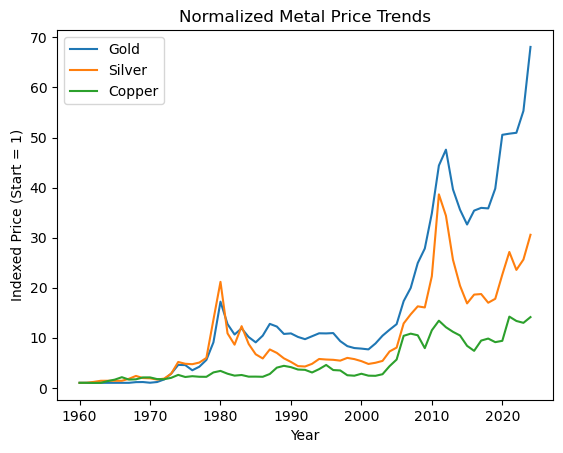

In [76]:
normalized = macro_annual[["Gold Price","Silver Price","Copper Price"]].div(
    macro_annual[["Gold Price","Silver Price","Copper Price"]].iloc[0]
)

plt.figure()

plt.plot(macro_annual["year"], normalized["Gold Price"], label="Gold")
plt.plot(macro_annual["year"], normalized["Silver Price"], label="Silver")
plt.plot(macro_annual["year"], normalized["Copper Price"], label="Copper")

plt.legend()

plt.title("Normalized Metal Price Trends")
plt.xlabel("Year")
plt.ylabel("Indexed Price (Start = 1)")

plt.show()

**Interpretation of the Normalized Price Chart**

Normalization removes the scale difference across metals and makes it easier to compare their **growth paths** over time.

Because gold, silver, and copper have very different absolute price levels, plotting the raw prices together can be misleading. After normalization, the chart shows **how much each metal grew** relative to its own starting point.

This makes it easier to see that gold and silver often follow more similar long-run patterns than gold and copper.

#### Which Metal Is More Stable?

Consumers often care not only about return, but also about **stability**. In investing, a more stable asset has smaller and less extreme price swings over time.

This section compares the volatility of gold, silver, and copper using both a numerical summary and a return distribution chart.

In [77]:
query_8 = """
-- Calculates the volatility (standard deviation) of annual returns for gold, silver, and copper.
-- How: Uses the variance formula based on averages of squared returns and mean returns, then applies a square root to obtain standard deviation.
-- Purpose: Volatility measures price stability, so comparing metals helps evaluate whether gold behaves as a relatively stable investment asset.

SELECT
    ROUND(
        SQRT(AVG(gold_change_pct * gold_change_pct) - AVG(gold_change_pct) * AVG(gold_change_pct)), 2
        ) AS gold_volatility,
    ROUND(
        SQRT(AVG(silver_change_pct * silver_change_pct) - AVG(silver_change_pct) * AVG(silver_change_pct)), 2
        ) AS silver_volatility,
    ROUND(
        SQRT(AVG(copper_change_pct * copper_change_pct) - AVG(copper_change_pct) * AVG(copper_change_pct)), 2
        ) AS copper_volatility
FROM macro_annual
WHERE gold_change_pct IS NOT NULL
    AND silver_change_pct IS NOT NULL
    AND copper_change_pct IS NOT NULL;
"""

gold_metal_volatility = pd.read_sql(query_8, conn)
gold_metal_volatility

,gold_volatility,silver_volatility,copper_volatility
0,21.46,28.55,21.67


**Interpretation of the Volatility Table**

The volatility calculations show that **silver is the most volatile metal** among the three, meaning it experiences the largest year-to-year swings.

Gold has similar but still lower volatility levels compared with copper. For a non-expert consumer, this suggests that **gold may offer a more balanced tradeoff between return and stability than silver.**

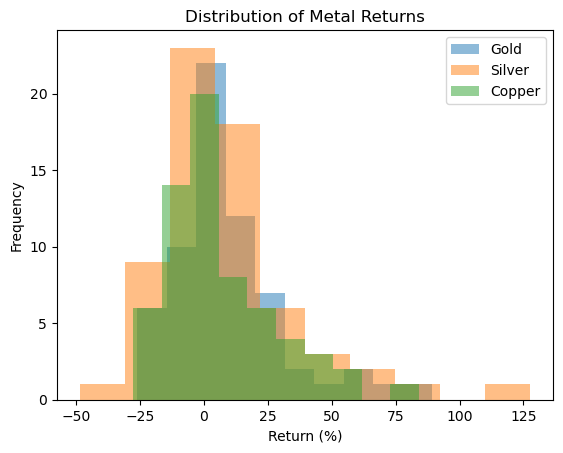

In [78]:
#The Distribution shows the spreadout of each change, silver is the most volatile one
plt.figure()

plt.hist(macro_annual["gold_change_pct"].dropna(), alpha=0.5, label="Gold")
plt.hist(macro_annual["silver_change_pct"].dropna(), alpha=0.5, label="Silver")
plt.hist(macro_annual["copper_change_pct"].dropna(), alpha=0.5, label="Copper")

plt.legend()

plt.title("Distribution of Metal Returns")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")

plt.show()

**Interpretation of the Return Distribution Chart**

The return distribution chart visually confirms the volatility results.

Silver’s returns are spread out more widely than those of gold and copper, which means that silver experiences more extreme positive and negative years. Gold’s distribution is comparatively tighter, which is consistent with the idea that it is more stable than silver.

### 5.10 Metals Across Inflation and GDP Regimes

After studying gold by itself and then comparing it with other metals, the next step is to combine those ideas.

This section asks a broader question:

**Which metal performs best under which type of economy?**

By comparing gold, silver, and copper across inflation and GDP growth regimes, we can see how each metal responds to different macroeconomic environments.

In [79]:
query_9 = """
-- Compares the average annual returns of gold, silver, and copper across different macroeconomic regimes.
-- How: Groups the dataset by inflation regime and GDP growth regime, then calculates the average return of each metal within each group.
-- Purpose: This helps evaluate whether gold behaves differently from other metals under varying economic conditions.

SELECT
    [Inflation Group] as inflation_group,
    [GDP Growth Group] as gdp_growth_group,
    ROUND(AVG(gold_change_pct),2) AS avg_gold_change_pct,
    ROUND(AVG(silver_change_pct),2) AS avg_silver_change_pct,
    ROUND(AVG(copper_change_pct),2) AS avg_copper_change_pct
FROM macro_annual
WHERE gold_change_pct IS NOT NULL
    AND silver_change_pct IS NOT NULL
    AND copper_change_pct IS NOT NULL
GROUP BY [Inflation Group], [GDP Growth Group]
ORDER BY inflation_group, gdp_growth_group;
"""
metal_price = pd.read_sql(query_9, conn)
metal_price

,inflation_group,gdp_growth_group,avg_gold_change_pct,avg_silver_change_pct,avg_copper_change_pct
0,High Inflation,High GDP Growth,11.62,11.75,13.22
1,High Inflation,Low GDP Growth,14.46,13.20,4.94
2,Low Inflation,High GDP Growth,0.19,5.97,7.07
3,Low Inflation,Low GDP Growth,6.94,4.26,-0.79


**Interpretation of Metal Returns Across Economic Regimes**

The grouped results show that the three metals respond to economic conditions in different ways.

- **Gold performs best during high inflation and weaker growth**, which is consistent with its role as a defensive asset.
- **Copper performs best during stronger growth**, reflecting its industrial use in production and construction.
- **Silver sits between the two**, behaving partly like a precious metal and partly like an industrial metal.

This comparison is especially important for consumers because it shows that metal choice depends on the type of economic environment they concern.

### 5.11 Long-Run Gold Price Pattern

So far, the analysis has focused mainly on annual returns and macroeconomic regimes. This final descriptive section steps back and asks a longer-run question:

**How does gold’s current price compare with its recent trend and What's the long-run development of gold in the future?**

Using a three-year moving comparison helps show when gold moves unusually far above or below its recent average level.

In [80]:
query_10 = """
-- Compares each year’s gold price with its recent 3-year average.
-- How: Uses a self-join on the Gold_annual table to match each year with itself and the prior two years, then calculates the average price over that 3-year window.
-- Purpose: This helps identify whether gold prices are unusually high or low relative to their recent trend, which supports the analysis of longer-run movement in gold prices.

SELECT
    a.year,
    ROUND(a.[Gold Price], 2) AS current_gold_price,
    ROUND(AVG(b.[Gold Price]), 2) AS gold_3yr_avg,
    ROUND(a.[Gold Price] - AVG(b.[Gold Price]), 2) AS gold_price_diff
FROM Gold_annual a
JOIN Gold_annual b
    ON b.year BETWEEN a.year - 2 AND a.year
GROUP BY a.year, a.[Gold Price]
ORDER BY a.year DESC;
"""

gold_price_3yr_avg = pd.read_sql(query_10, conn)
gold_price_3yr_avg

,year,current_gold_price,gold_3yr_avg,gold_price_diff
0,2026,5104.77,3660.63,1444.14
1,2025,3472.54,2610.27,862.27
2,2024,2404.58,2052.41,352.17
3,2023,1953.69,1848.46,105.23
4,2022,1798.96,1792.12,6.84
...,...,...,...,...
107,1919,20.03,19.84,0.19
108,1918,19.84,19.66,0.18
109,1917,19.66,19.46,0.20
110,1916,19.47,19.36,0.11


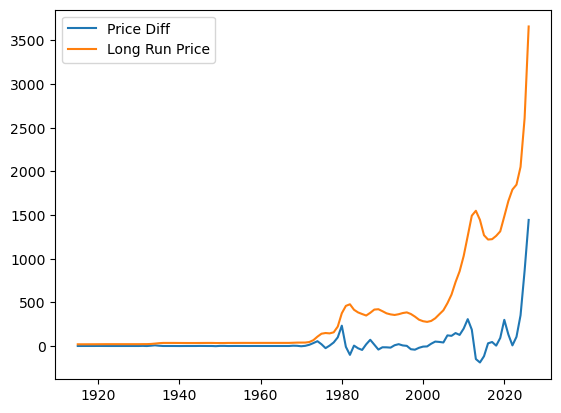

In [81]:
plt.plot(gold_price_3yr_avg["year"], gold_price_3yr_avg["gold_price_diff"], label="Price Diff")
plt.plot(gold_price_3yr_avg["year"], gold_price_3yr_avg["gold_3yr_avg"], label="Long Run Price")

plt.legend()

**Interpretation of the Long-Run Gold Trend**

The table and chart compare each year’s gold price with its recent three-year average.

Before the 1980s, gold stayed **relatively close to its short-run trend**, but larger deviations appear during later periods of economic turbulence. In recent years, the gap becomes especially large, suggesting that **gold moved well above its recent trend**.

This reinforces the broader conclusion of the notebook: **gold often becomes especially attractive when the economic environment feels unstable.**

### 5.12 Regression Analysis: Determinants of Gold Returns

The earlier sections used tables and charts to describe patterns in the data. Regression analysis adds a more formal test by estimating how strongly gold returns are associated with macroeconomic variables and with the returns of other metals.

Three models are used:

1. a **macroeconomic model** using GDP growth and inflation,
2. a **metal comparison model** using silver and copper returns,
3. and a **combined model** including both macroeconomic and metal variables.

The purpose of these models is not to predict gold perfectly, but to identify **which factors are most strongly linked to gold’s performance.**

#### Model 1 — Macroeconomic Factors

The first model asks whether gold returns are related to broad economic conditions.

Specifically, it tests whether gold tends to rise when inflation is higher and whether gold behaves differently when GDP growth is stronger or weaker.

In [84]:
import statsmodels.api as sm

y = macro_annual["gold_change_pct"].dropna()

X = macro_annual[["gdp_growth_pct", "inflation_change"]].dropna()
X = sm.add_constant(X)

model1 = sm.OLS(y, X).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:        gold_change_pct   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     12.51
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           2.79e-05
Time:                        21:27:11   Log-Likelihood:                -276.04
No. Observations:                  64   AIC:                             558.1
Df Residuals:                      61   BIC:                             564.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               16.9762      4.161  

**Interpretation of Model 1**

The results show that inflation has a **positive and statistically significant** relationship with gold returns. This means that, holding the other variable constant, gold tends to perform better when inflation is higher.

GDP growth has a **negative coefficient**, which suggests that gold tends to perform less strongly when the economy is growing more quickly. However, in this model the GDP effect is **weaker** than the inflation effect.

The model explains a moderate share of the variation in gold returns, which is reasonable because financial returns are influenced by many factors that are not included here.

Overall, Model 1 supports the idea that gold tends to be more attractive in inflationary environments and may be less central during periods of strong economic growth.

#### Model 2 — Comparison with Substitute Metals

The second model examines whether gold moves together with silver and copper.

This is useful because silver and copper represent two different kinds of metal: silver is closer to gold as a precious metal, while copper is more strongly tied to industrial demand.

In [85]:
y = macro_annual["gold_change_pct"].dropna()

X = macro_annual[["silver_change_pct", "copper_change_pct"]].dropna()
X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:        gold_change_pct   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     49.46
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           1.72e-13
Time:                        21:27:14   Log-Likelihood:                -256.20
No. Observations:                  64   AIC:                             518.4
Df Residuals:                      61   BIC:                             524.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 3.7209      1.79

**Interpretation of Model 2**

The results show that **silver returns are strongly and positively associated with gold returns**. In practical terms, when silver has a strong year, gold also tends to perform well.

By contrast, **copper does not show a meaningful relationship with gold returns** in this model. This suggests that gold does not move closely with industrial metal performance.

This is an important result because it supports the idea that gold behaves more like another precious metal than like an industrial commodity.

Model 2 also explains a larger share of gold-return variation than Model 1, which suggests that gold’s relationship with other metals — especially silver — is a strong part of the story.

#### Model 3 — All Factors Combined

The final model combines both macroeconomic variables and metal returns in one regression.

This is the most complete model in the notebook because it asks whether inflation, GDP growth, silver, and copper still matter when all are considered together.

In [86]:
y = macro_annual["gold_change_pct"].dropna()

X = macro_annual[["gdp_growth_pct", "Inflation Rate","silver_change_pct", "copper_change_pct"]].dropna()
X = sm.add_constant(X)

model3 = sm.OLS(y, X).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:        gold_change_pct   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     28.85
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           2.67e-13
Time:                        21:27:19   Log-Likelihood:                -252.36
No. Observations:                  64   AIC:                             514.7
Df Residuals:                      59   BIC:                             525.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.3264      3.94

**Interpretation of Model 3**

The combined model shows that **inflation** and **silver returns** remain the most important variables.

Inflation continues to have a **positive relationship** with gold returns, which supports the idea that gold tends to perform better in inflationary environments. Silver also remains **strongly and positively related** to gold, reinforcing the finding that gold behaves more like a precious metal than an industrial one.

GDP growth has a **negative** sign, which is consistent with the idea that gold may be less attractive when the economy is expanding strongly, but its effect is weaker in the combined model. Copper again shows **little relationship** with gold.

Taken together, the combined model suggests that gold’s behavior is shaped more by **inflation conditions and precious-metal market movements** than by industrial commodity forces.

---

## 6. Conclusion

This project examined how gold behaves under different economic conditions using historical data on gold, silver, copper, inflation, and GDP growth. By combining exploratory data analysis, SQL queries, visualizations, and regression models, the analysis aimed to better understand when gold tends to perform well and how it compares with other metals.

### Several key findings emerge from the results:

- First, gold tends to perform more strongly during **high inflation environments**. Both the subgroup analysis and SQL queries show that many of gold’s strongest years occurred when inflation was elevated. In several of these cases, gold returns exceeded the inflation rate itself, suggesting that gold can help preserve purchasing power during periods of rising prices.

- Second, gold often performs well during **low GDP growth periods**. When economic growth slows or becomes uncertain, gold returns frequently exceed their long-run average. This supports the idea that gold may function as a defensive asset during weaker economic conditions.

- Third, gold behaves more similarly to **silver than to copper**. Regression results and correlation analysis show that gold returns are strongly associated with silver returns, while copper — an industrial metal — has a much weaker relationship with gold. This indicates that gold is influenced more by financial market dynamics and investor behavior than by industrial demand.

- Finally, the volatility comparison shows that gold provides a **more balanced combination of return and stability** among the three metals examined, with silver being the most volatile metal.

### Limitations

Despite these insights, the analysis has several limitations:

- First, the dataset includes only **a limited set of variables**. Gold prices can be influenced by many additional factors such as interest rates, exchange rates, geopolitical events, central bank policies, and investor sentiment. These factors were not included in the current models.

- Second, the analysis focuses on **annual data**, which may **hide short-term fluctuations in gold prices**. Gold markets often react quickly to economic news, so higher-frequency data (such as monthly or daily prices) could reveal additional patterns.

- Third, regression models in this project identify **associations rather than causal relationships**. While the results suggest that inflation and silver returns are related to gold performance, they do not prove that these factors directly cause changes in gold prices.

### Future Directions

Future research could extend this analysis in several ways:

- One possible improvement would be to incorporate additional macroeconomic variables such as **interest rates, real interest rates, exchange rates, or monetary policy indicators**, which are often cited as key drivers of gold prices.

- Another extension would be to analyze **higher-frequency data**, such as monthly or daily observations, to better capture short-term market reactions.

- Finally, more advanced modeling approaches, such as time-series models or machine learning techniques, could be used to explore whether gold price movements can be predicted more accurately.

Overall, this analysis suggests that gold tends to perform best during periods of **inflation and economic uncertainty**, supporting its reputation as a good potential defensive asset compared to silver and copper for non-expert investors.